In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [17]:
df = pd.read_csv("../data/uav_fault_dataset.csv")

In [18]:
df.columns

Index(['bag', 'timestamp_ns', 'roll_cmd', 'roll_meas', 'roll_error',
       'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas',
       'yaw_error', 'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z',
       'engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault',
       'ground_speed'],
      dtype='object')

# fault Verify

In [19]:
for col in ["engine_fault", "aileron_fault", "elevator_fault", "rudder_fault"]:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


engine_fault
engine_fault
0    162542
1     18270
Name: count, dtype: int64

aileron_fault
aileron_fault
0    173855
1      3043
2      2929
3       985
Name: count, dtype: int64

elevator_fault
elevator_fault
0    180359
1       453
Name: count, dtype: int64

rudder_fault
rudder_fault
0    179507
1       523
2       176
3       606
Name: count, dtype: int64


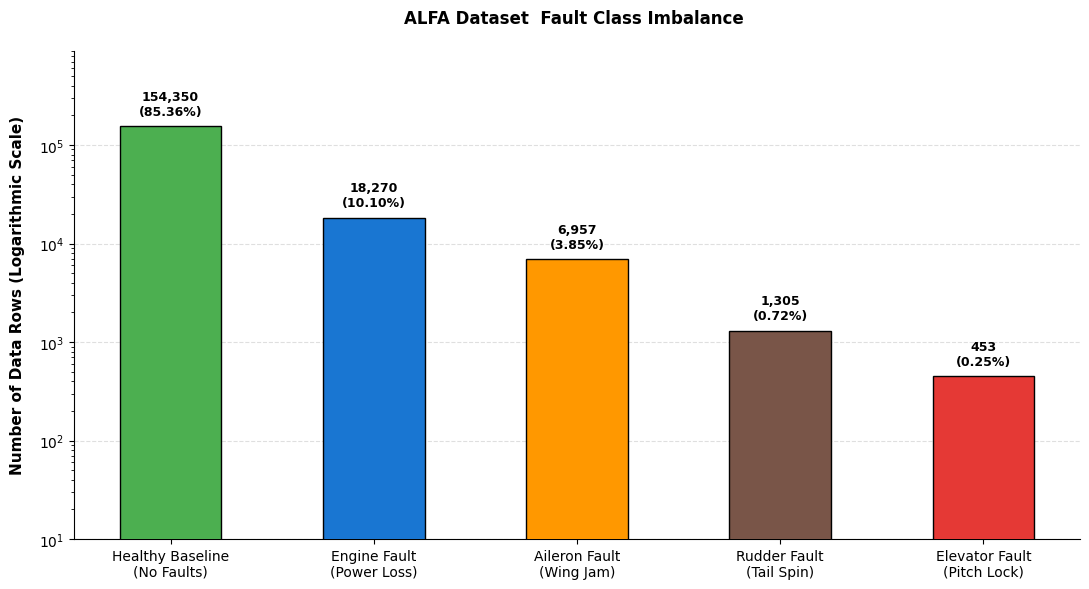

In [22]:
healthy_count = len(df[(df['engine_fault'] == 0) & (df['aileron_fault'] == 0) & 
                       (df['elevator_fault'] == 0) & (df['rudder_fault'] == 0)])

# Sum any row where the specific sensor flag is active (> 0)
engine_count = (df['engine_fault'] > 0).sum()
aileron_count = (df['aileron_fault'] > 0).sum()
rudder_count = (df['rudder_fault'] > 0).sum()
elevator_count = (df['elevator_fault'] > 0).sum()
total_rows = len(df)

# 2. Package the numbers for checking the imbalance
fault_labels = [
    'Healthy Baseline\n(No Faults)', 
    'Engine Fault\n(Power Loss)', 
    'Aileron Fault\n(Wing Jam)', 
    'Rudder Fault\n(Tail Spin)', 
    'Elevator Fault\n(Pitch Lock)'
]
fault_counts = [healthy_count, engine_count, aileron_count, rudder_count, elevator_count]
fault_pcts = [(cnt / total_rows) * 100 for cnt in fault_counts]

# 3. Render the Academic Visualization
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(11, 6))

# Color palette to easily distinguish component-level failures
colors = ['#4caf50', '#1976d2', '#ff9800', '#795548', '#e53935']

bars = ax.bar(fault_labels, fault_counts, color=colors, edgecolor='black', width=0.5, zorder=3)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# Annotate each individual bar with its exact row footprint and percentage
for bar, pct in zip(bars, fault_pcts):
    height = bar.get_height()
    ax.annotate(f'{int(height):,}\n({pct:.2f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Formal axis labels and titles
ax.set_title('ALFA Dataset  Fault Class Imbalance ', 
             fontsize=12, fontweight='bold', pad=20)

# Use Log Scale because elevator (453) is completely hidden next to healthy (154,350)
ax.set_yscale('log')
ax.set_ylabel('Number of Data Rows (Logarithmic Scale)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylim(10, total_rows * 5) 

# Remove top and right borders for presentation aesthetic
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
df['binary_fault'] = np.where(
    (df['engine_fault'] > 0) | 
    (df['aileron_fault'] > 0) | 
    (df['elevator_fault'] > 0) | 
    (df['rudder_fault'] > 0), 
    1, 0
)

# 2. Extract actual value distributions directly from your DataFrame
binary_counts = df['binary_fault'].value_counts()
total_rows = len(df)

binary_labels = {
    0: "Class 0: Healthy Baseline",
    1: "Class 1: Combined Flight Fault"
}

# 3. Print out the exact statistical split for verification
for class_id in sorted(binary_labels.keys()):
    cnt = binary_counts.get(class_id, 0)
    pct = (cnt / total_rows) * 100
    print(f"-> {binary_labels[class_id]:<30} : {cnt:>7,} rows ({pct:.2f}%)")

print(f"\nTotal Confirmed Rows in Memory: {total_rows:,}")
print(f"Updated Column Index List:\n{list(df.columns)}")

binary_csv_path = "uav_fault_dataset_v1.csv"

print(f"[STATUS] Writing unified binary dataset to: {binary_csv_path}...")
df.to_csv(binary_csv_path, index=False)


-> Class 0: Healthy Baseline      : 154,350 rows (85.36%)
-> Class 1: Combined Flight Fault :  26,462 rows (14.64%)

Total Confirmed Rows in Memory: 180,812
Updated Column Index List:
['bag', 'timestamp_ns', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error', 'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault', 'ground_speed', 'binary_fault']
[STATUS] Writing unified binary dataset to: uav_fault_dataset_v1.csv...


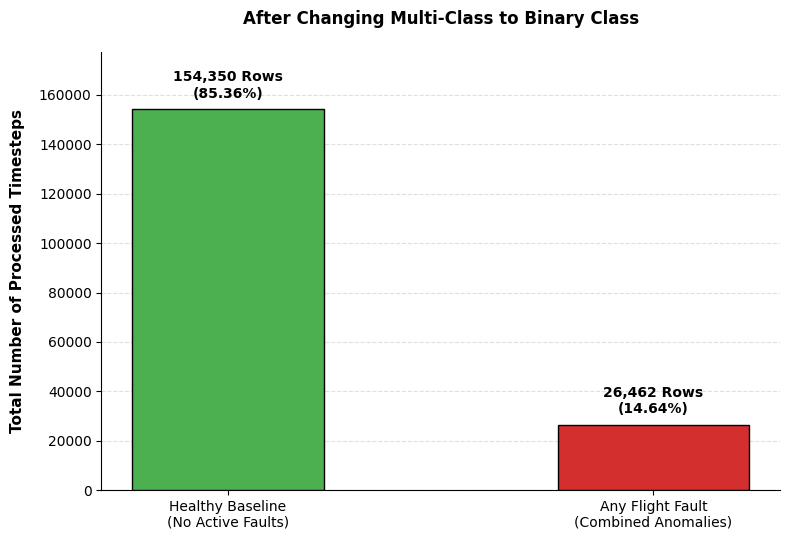

In [26]:
binary_counts = df['binary_fault'].value_counts()
total_timesteps = len(df)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

fig, ax = plt.subplots(figsize=(8, 5.5))

labels = ['Healthy Baseline\n(No Active Faults)', 'Any Flight Fault\n(Combined Anomalies)']
final_counts = [binary_counts.get(0, 0), binary_counts.get(1, 0)]
final_pcts = [(count / total_timesteps) * 100 for count in final_counts]

# Academic color canvas palette: Forest Green for safe flight, Crimson Red for active anomalies
colors = ['#4caf50', '#d32f2f'] 

# Render the bar chart
bars = ax.bar(labels, final_counts, color=colors, edgecolor='black', width=0.45, zorder=3)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# Dynamically annotate the exact row count and percentage directly on top of each bar
for bar, pct in zip(bars, final_pcts):
    height = bar.get_height()
    ax.annotate(f'{int(height):,} Rows\n({pct:.2f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formal axis labels and thesis titles
ax.set_ylabel('Total Number of Processed Timesteps', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('After Changing Multi-Class to Binary Class', 
             fontsize=12, fontweight='bold', pad=20)

# Give vertical buffer headroom at the top of the chart for the text markers
ax.set_ylim(0, max(final_counts) * 1.15) 

# Eliminate top and right boundary grid lines for a professional thesis look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()
